**Group 6 - ML Assignment**

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import pandas as pd
df = pd.read_csv( "/content/drive/MyDrive/Colab Notebooks/adult.csv")
df.head()
#df.info()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


**Data Exploration and Preprocessing:**

Importing libraries:

In [4]:
import numpy as np
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler


In [5]:
# 1. Summarize the structure and characteristics of the adult dataset

print(df.shape)
print(df.info())

(48842, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB
None


In [6]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
educational-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


In [7]:
# 2. Identify variables and their types
numerical_features = df.select_dtypes(include='number').columns.tolist()
categorical_features = df.select_dtypes(include='object').columns.tolist()
df.describe(include="object").T


,count,unique,top,freq
workclass,48842,9,Private,33906
education,48842,16,HS-grad,15784
marital-status,48842,7,Married-civ-spouse,22379
occupation,48842,15,Prof-specialty,6172
relationship,48842,6,Husband,19716
race,48842,5,White,41762
gender,48842,2,Male,32650
native-country,48842,42,United-States,43832
income,48842,2,<=50K,37155


In [8]:
# Drop the 'fnlwgt' column from the DataFrame as it doesnot give a meaningful interpretation.
df = df.drop(columns=['fnlwgt'])


In [9]:
df.education.value_counts
# Similar columns, therefore we need to remove one of them
df.groupby("education")["educational-num"].value_counts(dropna=False)

,,count
education,educational-num,
10th,6,1389
11th,7,1812
12th,8,657
1st-4th,2,247
5th-6th,3,509
7th-8th,4,955
9th,5,756
Assoc-acdm,12,1601
Assoc-voc,11,2061


In [10]:
# Drop the 'education' column from the DataFrame as it doesnot give new information to the model.
# This column is same as "education_num" column
df = df.drop(columns=['education'])

Handle Missing Values:

In [11]:
df.duplicated().sum()


6374

In [12]:
df[df.duplicated()]
# However when we go through these values we can see that none of the rows have been duplicated entirely only a few features have similar values.

,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
595,59,Private,9,Divorced,Other-service,Not-in-family,White,Female,0,0,40,United-States,<=50K
653,32,Private,9,Married-civ-spouse,Sales,Husband,White,Male,0,0,40,United-States,<=50K
741,40,Private,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
864,24,Private,13,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,35,United-States,<=50K
1131,44,Private,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,99999,0,60,United-States,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48784,47,Private,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
48793,20,Private,9,Never-married,Machine-op-inspct,Own-child,White,Male,0,0,40,United-States,<=50K
48808,22,Private,10,Never-married,Adm-clerical,Own-child,White,Male,0,0,40,United-States,<=50K
48838,40,Private,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K


In [13]:
# Handle Missing Values:
count = df.isnull().sum()
missing_df = pd.DataFrame({"count": count})
missing_df

,count
age,0
workclass,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0
capital-gain,0
capital-loss,0


In [14]:
df.isin(["?"]).sum()
# It can be seen that a "?" is included in some entries for column workclass,occupation and native country, therefore we will have to handle them considering them as missing values.

,0
age,0
workclass,2799
educational-num,0
marital-status,0
occupation,2809
relationship,0
race,0
gender,0
capital-gain,0
capital-loss,0


In [15]:
# Imputation

df.workclass = df.workclass.replace("?", "Private")
# The entries with "?" in the workclass were replaced with "Private" because it is the most frequent value (mode imputation) in the workclass data.

In [16]:
df['native-country'] = df['native-country'].replace("?", "United-States")
# The same imputation method was applied here as "United States" was the most frequent value.

In [17]:
df.replace({'occupation': '?'}, value=np.nan, inplace=True)
df['occupation'] = df['occupation'].ffill()

# Here "?" in the occupation column was replaced using the "forward fill" technique.

In [18]:
df.isin(["?"]).sum()


,0
age,0
workclass,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0
capital-gain,0
capital-loss,0


Encode Categorical Variables:

In [19]:

# Identify nominal columns, excluding 'native-country' for manual processing
nominal_cols = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'income']

# Create the column 'native-country-US'
df['native-country-US'] = (df['native-country'] == 'United-States').astype(float)

# Create the column 'native-country-Others'
df['native-country-Others'] = 1 - df['native-country-US']

# Encode remaining nominal columns using One-Hot Encoding
ohe = OneHotEncoder(sparse_output=False, drop='first')
encoded_nominal = pd.DataFrame(ohe.fit_transform(df[nominal_cols]), columns=ohe.get_feature_names_out(nominal_cols))

# Concatenate the encoded nominal columns with the original DataFrame, dropping the processed nominal columns
df = pd.concat([df.drop(columns=nominal_cols), encoded_nominal], axis=1)

# Drop 'native-country' if it's still there
if 'native-country' in df.columns:
    df.drop(columns=['native-country'], inplace=True)

# Display the first few rows to confirm changes
print(df.head())


   age  educational-num  capital-gain  capital-loss  hours-per-week  \
0   25                7             0             0              40   
1   38                9             0             0              50   
2   28               12             0             0              40   
3   44               10          7688             0              40   
4   18               10             0             0              30   

   native-country-US  native-country-Others  workclass_Local-gov  \
0                1.0                    0.0                  0.0   
1                1.0                    0.0                  0.0   
2                1.0                    0.0                  1.0   
3                1.0                    0.0                  0.0   
4                1.0                    0.0                  0.0   

   workclass_Never-worked  workclass_Private  ...  \
0                     0.0                1.0  ...   
1                     0.0                1.0  ...   
2    

Scale Numerical Features:

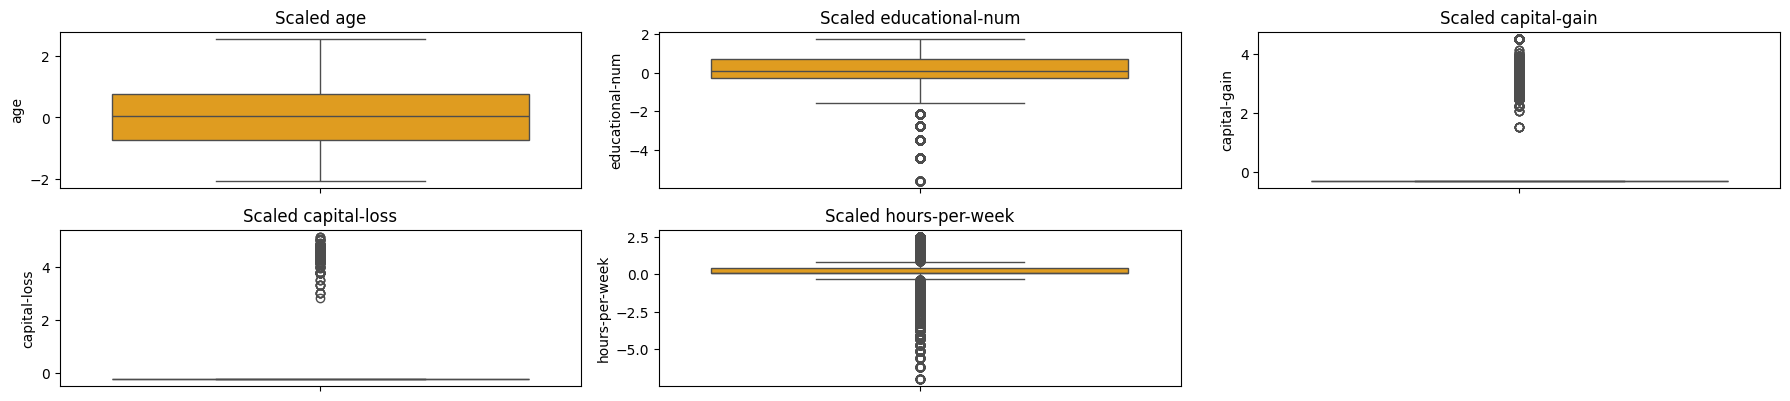

In [20]:
# Define the constant C for log transformation
C = 1  # You can adjust this based on your dataset and scaling needs

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply log transformation and scaling to all numeric columns in the original DataFrame
for col in df.select_dtypes(include=['int64']).columns:
    # Log transformation with constant C
    df[col] = np.log1p(df[col] + C)  # log1p(x + C)
    # Apply Standard Scaler to log-transformed data
    df[col] = scaler.fit_transform(df[[col]])

# Exclude one-hot encoded columns (e.g., 'income_>50K' and others)
exclude_columns = df.filter(regex='income_>50K|native-country|workclass|marital-status|occupation|relationship|race|gender').columns

# Get the columns to plot (excluding the one-hot encoded columns and 'income_>50K')
columns_to_plot = df.select_dtypes(include=['float64', 'int64']).drop(columns=exclude_columns)

# Visualize the scaled data (box plots for numerical columns)
plt.figure(figsize=(18, 12))
for i, col in enumerate(columns_to_plot.columns):
    plt.subplot(6, 3, i + 1)
    sns.boxplot(data=df, y=col, color='orange')
    plt.title(f'Scaled {col}')

plt.tight_layout()
plt.show()



**Exploratory Data Analysis (EDA):**

Detecting and Handling outliers:

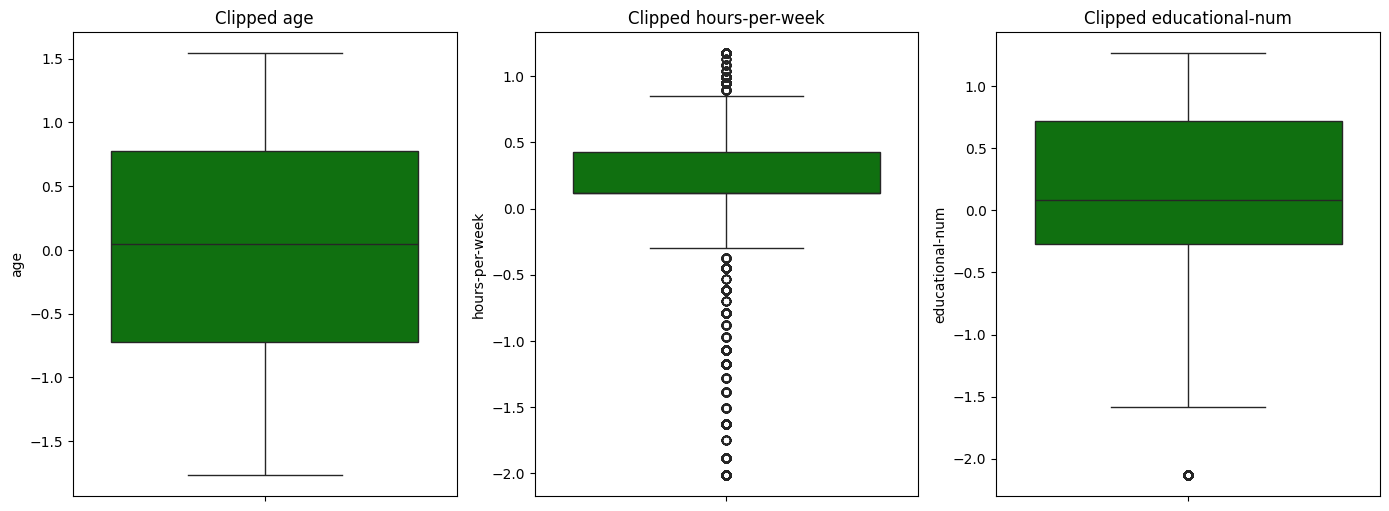

In [21]:

# List of columns to apply clipping, including 'educational-num'
columns_to_clip = ['age', 'hours-per-week', 'educational-num']  # Add 'educational-num' here

# Define the lower and upper percentiles for clipping (e.g., 5th and 95th percentile)
lower_percentile = 0.05
upper_percentile = 0.95

# Apply clipping to selected columns in the original DataFrame
for col in columns_to_clip:
    lower_limit = df[col].quantile(lower_percentile)
    upper_limit = df[col].quantile(upper_percentile)

    # Clip the values to the specified percentiles
    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

# Visualize the original and clipped data using boxplots to compare
plt.figure(figsize=(14, 10))

# Boxplots after clipping (Clipped Data)
for i, col in enumerate(columns_to_clip):
    plt.subplot(2, len(columns_to_clip), len(columns_to_clip) + i + 1)
    sns.boxplot(data=df, y=col, color='green')
    plt.title(f'Clipped {col}')

plt.tight_layout()
plt.show()



Histograms:

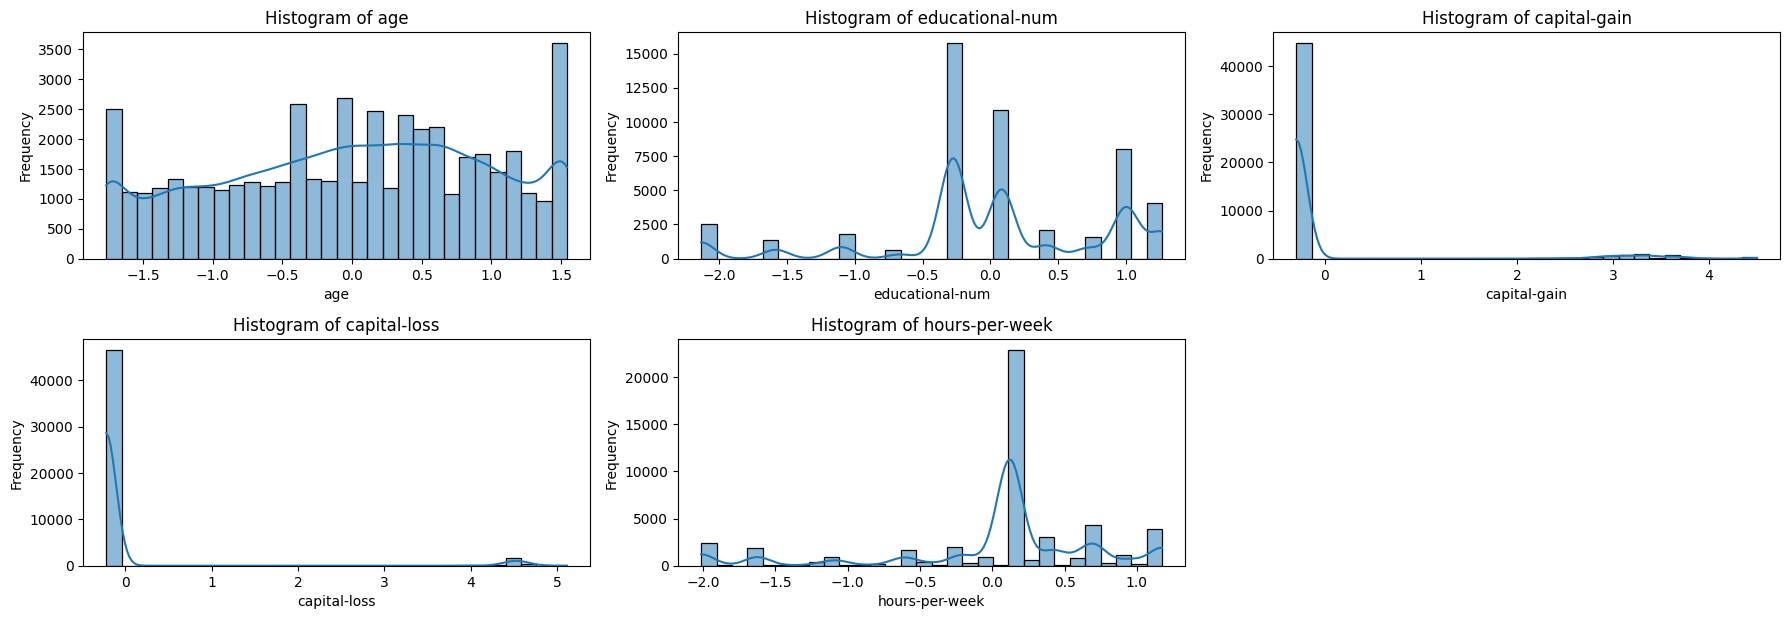

In [22]:
# Exclude one-hot encoded columns and 'income_>50K' column from the scaled dataset
exclude_columns = df.filter(regex='income_>50K|native-country|workclass|marital-status|occupation|relationship|race|gender').columns

# Get the columns to plot (excluding the specified columns)
columns_to_plot = df.select_dtypes(include=['float64', 'int64']).drop(columns=exclude_columns)

# Set up the plotting area with enough room for histograms
plt.figure(figsize=(18, 12))  # Adjust figure size for better spacing

# Loop through each feature and draw a histogram
for i, column in enumerate(columns_to_plot.columns, 1):
    plt.subplot(4, 3, i)  # Create a 4x3 grid for 12 features (adjust rows/columns as needed)
    sns.histplot(data=df, x=column, bins=30, kde=True)  # Adding kde=True for kernel density estimate
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()  # Adjust spacing
plt.show()

Pairplots:

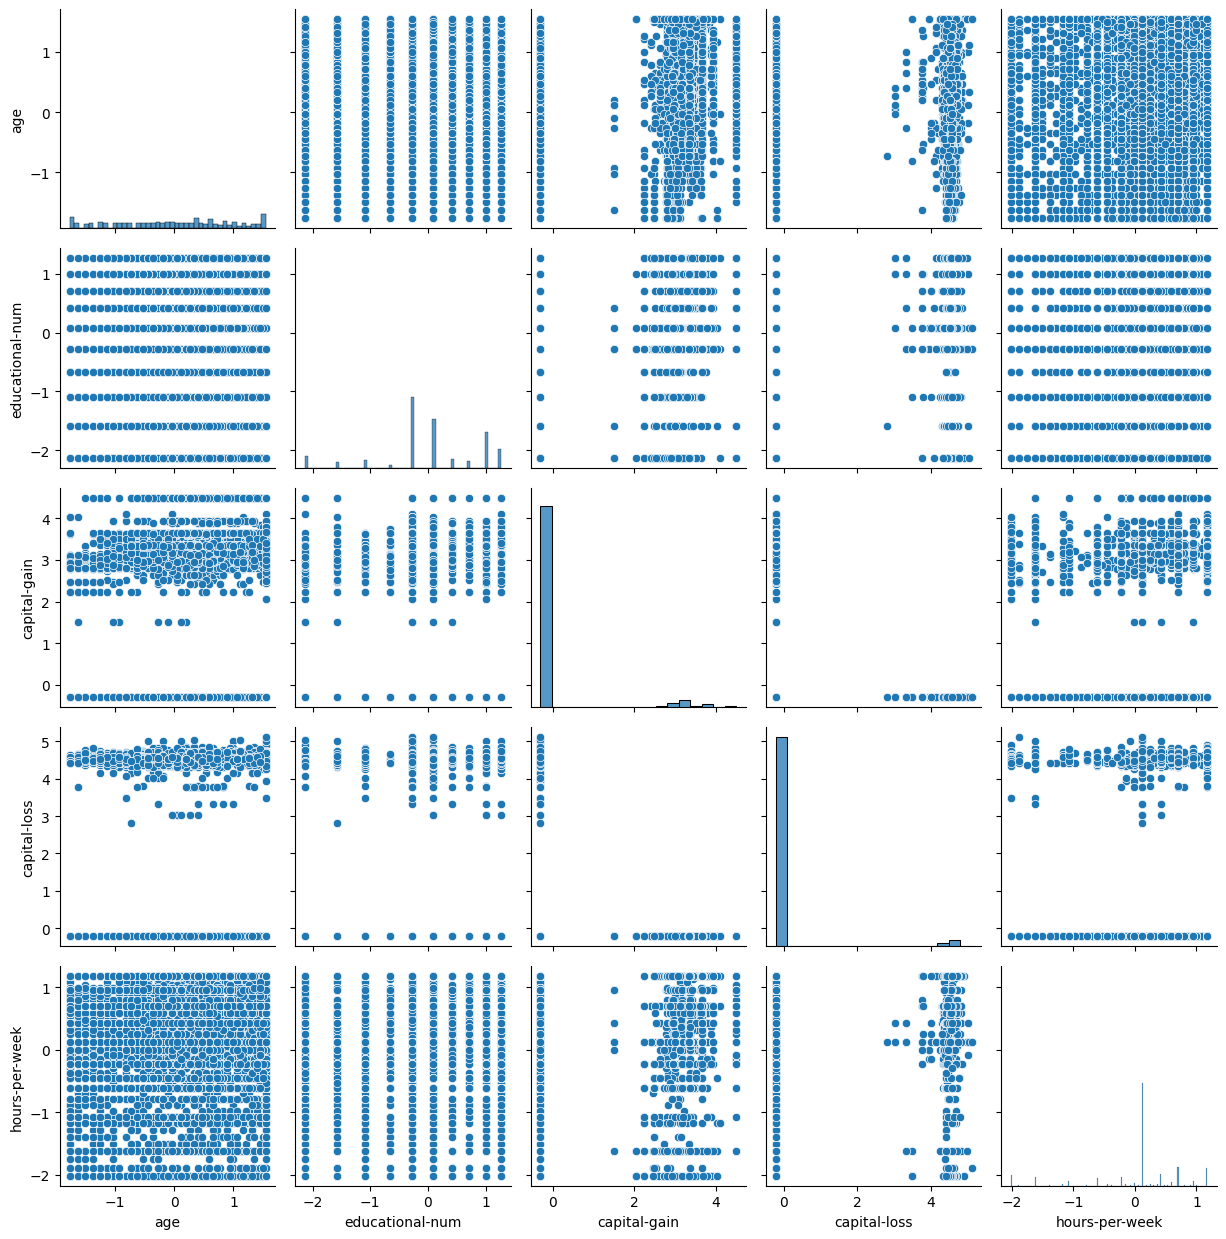

In [23]:

# Exclude one-hot encoded columns and 'income_>50K' column from the scaled dataset
exclude_columns = df.filter(regex='income_>50K|native-country|workclass|marital-status|occupation|relationship|race|gender').columns

# Get the columns to plot (excluding the specified columns)
columns_to_plot = df.select_dtypes(include=['float64', 'int64']).drop(columns=exclude_columns)

# Set up the pairplot for the selected numeric columns
sns.pairplot(columns_to_plot)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


Heatmap:

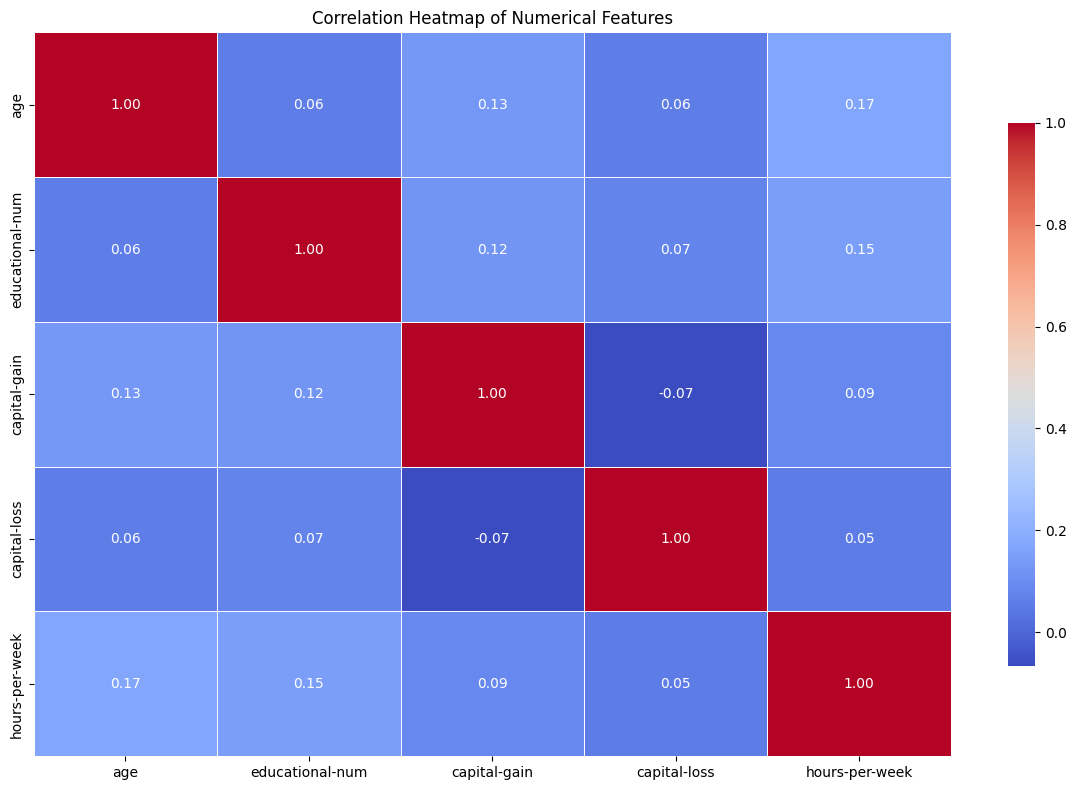

In [24]:


# Exclude unwanted columns explicitly
exclude_columns = df.filter(regex='income_>50K|native-country|workclass|marital-status|occupation|relationship|race|gender').columns

# Select strictly numerical columns for the heatmap
columns_to_plot = df.select_dtypes(include=['float64', 'int64']).drop(columns=exclude_columns).columns

# Compute the correlation matrix for selected columns
corr_matrix = df[columns_to_plot].corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, cbar_kws={"shrink": 0.75})
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()


Pivot Table:

In [25]:
# List of categorical variables that are one-hot encoded
categorical_variables = ['workclass', 'marital-status', 'occupation','relationship','race', 'gender','native-country']

# Initialize an empty list to store results
all_grouped_results = []

# Loop through each categorical variable
for var in categorical_variables:
    # Get the one-hot encoded columns for the current categorical variable
    var_columns = [col for col in df.columns if f'{var}_' in col]

    # Loop through each one-hot encoded column to compute aggregations
    for col in var_columns:
        # Filter rows where the column value is 1 (i.e., category present)
        temp_df = df[df[col] == 1]

        # Perform aggregation
        aggregation = {
            'variable': var,  # Keep track of the categorical variable
            'category': col,  # Keep track of the category (column name)
            'average_age': temp_df['age'].mean(),
            'average_hours_per_week': temp_df['hours-per-week'].mean(),
            'average_educational_num': temp_df['educational-num'].mean(),
            'count': temp_df['age'].size
        }

        all_grouped_results.append(aggregation)

# Convert the results into a DataFrame
grouped_df = pd.DataFrame(all_grouped_results)

# Display the result
print("Grouped by One-Hot Encoded Categorical Variables with Aggregation:")
print(grouped_df)


Grouped by One-Hot Encoded Categorical Variables with Aggregation:
          variable                              category  average_age  \
0        workclass                   workclass_Local-gov     0.244538   
1        workclass                workclass_Never-worked    -1.563575   
2        workclass                     workclass_Private    -0.121024   
3        workclass                workclass_Self-emp-inc     0.508462   
4        workclass            workclass_Self-emp-not-inc     0.460059   
5        workclass                   workclass_State-gov     0.088962   
6        workclass                 workclass_Without-pay     0.374105   
7   marital-status      marital-status_Married-AF-spouse    -0.484052   
8   marital-status     marital-status_Married-civ-spouse     0.368612   
9   marital-status  marital-status_Married-spouse-absent     0.156713   
10  marital-status          marital-status_Never-married    -0.825330   
11  marital-status              marital-status_Separated 

**Model Training and Evaluation:**

In [26]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

Target Variable: ['income_>50K']
Features: ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country-US', 'native-country-Others', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'marital-status_Married-AF-spouse', 'marital-status_Married-civ-spouse', 'marital-status_Married-spouse-absent', 'marital-status_Never-married', 'marital-status_Separated', 'marital-status_Widowed', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Exec-managerial', 'occupation_Farming-fishing', 'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct', 'occupation_Other-service', 'occupation_Priv-house-serv', 'occupation_Prof-specialty', 'occupation_Protective-serv', 'occupation_Sales', 'occupation_Tech-support', 'occupation_Transport-moving', 'relationship_Not-in-family', 'relationship_Other-relative', 'relationship_Own-child', '

Text(0.5, 1.0, 'Class Distribution of Target Variable')

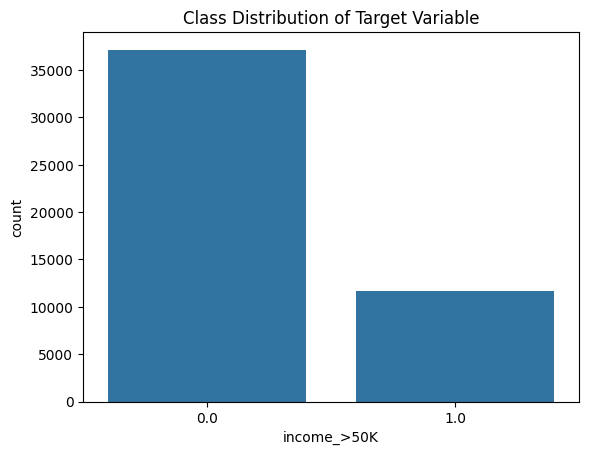

In [27]:
# Define the target variable and features
target_variable=['income_>50K']
features = [col for col in df.columns if col not in target_variable]

print("Target Variable:", target_variable)
print("Features:", features)

# Check the class distribution
print(df["income_>50K"].value_counts())

# Visualize class distribution
sns.countplot(x='income_>50K', data=df)
plt.title('Class Distribution of Target Variable')


In [28]:

X = df[features].to_numpy() # 2D array (features)
y = df['income_>50K'].to_numpy()

 # Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Check the new shape of the resampled data
print("Original dataset shape:", pd.Series(y).value_counts())
print("Resampled dataset shape:", pd.Series(y_resampled).value_counts())



Original dataset shape: 0.0    37155
1.0    11687
Name: count, dtype: int64
Resampled dataset shape: 0.0    37155
1.0    37155
Name: count, dtype: int64


Data splitting and training:

In [29]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled,test_size=0.2, random_state=42)


In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

log_reg = LogisticRegression()
rf_classifier = RandomForestClassifier(random_state=42)
gb_classifier = GradientBoostingClassifier(random_state=42)

# Train the models on the training set
log_reg.fit(X_train, y_train)
rf_classifier.fit(X_train, y_train)
gb_classifier.fit(X_train, y_train)




GradientBoostingClassifier(random_state=42)

Evaluation Metrics:

Model: LogisticRegression

Training Metrics:
Accuracy: 0.8218
Precision: 0.8054
Recall: 0.8488
F1-score: 0.8265
AUC-ROC: 0.9052

Testing Metrics:
Accuracy: 0.8285
Precision: 0.8126
Recall: 0.8538
F1-score: 0.8327
AUC-ROC: 0.9080



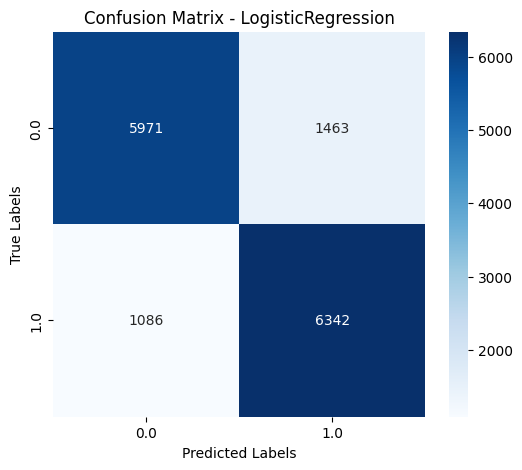


Model: RandomForestClassifier

Training Metrics:
Accuracy: 0.9767
Precision: 0.9717
Recall: 0.9820
F1-score: 0.9768
AUC-ROC: 0.9977

Testing Metrics:
Accuracy: 0.8898
Precision: 0.8900
Recall: 0.8895
F1-score: 0.8897
AUC-ROC: 0.9559



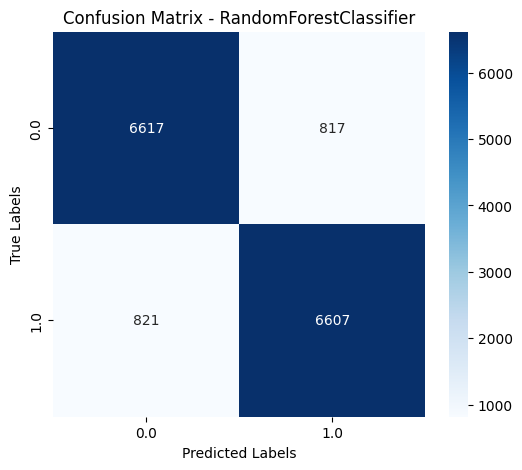


Model: GradientBoostingClassifier

Training Metrics:
Accuracy: 0.8619
Precision: 0.8403
Recall: 0.8938
F1-score: 0.8662
AUC-ROC: 0.9426

Testing Metrics:
Accuracy: 0.8628
Precision: 0.8447
Recall: 0.8889
F1-score: 0.8663
AUC-ROC: 0.9423



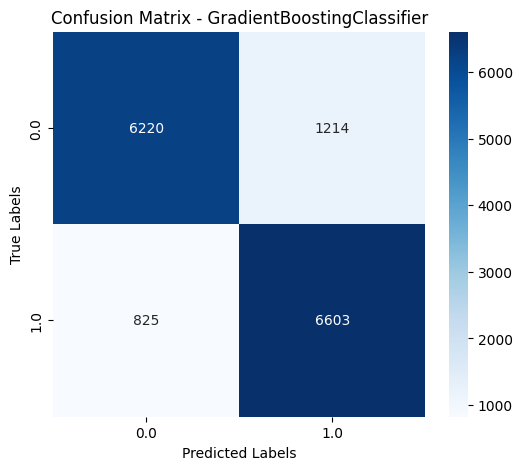

In [31]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)


# Function to evaluate classification models
def evaluate_classification_model(model, X_train, y_train, X_test, y_test):
    # Predictions on training data
    y_train_pred = model.predict(X_train)
    y_train_prob = model.predict_proba(X_train)[:, 1]

    # Predictions on test data
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    # Training set metrics
    train_metrics = {
        "Accuracy": accuracy_score(y_train, y_train_pred),
        "Precision": precision_score(y_train, y_train_pred),
        "Recall": recall_score(y_train, y_train_pred),
        "F1-score": f1_score(y_train, y_train_pred),
        "AUC-ROC": roc_auc_score(y_train, y_train_prob),
    }

    # Testing set metrics
    test_metrics = {
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred),
        "Recall": recall_score(y_test, y_test_pred),
        "F1-score": f1_score(y_test, y_test_pred),
        "AUC-ROC": roc_auc_score(y_test, y_test_prob),
    }

    # Print evaluation metrics
    print(f"Model: {model.__class__.__name__}")
    print("")

    print("Training Metrics:")
    for metric, value in train_metrics.items():
        print(f"{metric}: {value:.4f}")
    print("\nTesting Metrics:")
    for metric, value in test_metrics.items():
        print(f"{metric}: {value:.4f}")
    print("")

    # Confusion Matrix for Test Data
    cm = confusion_matrix(y_test, y_test_pred)
    labels = [str(i) for i in sorted(set(y_test))]  # Dynamically set labels
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix - {model.__class__.__name__}')
    plt.ylabel('True Labels')
    plt.xlabel('Predicted Labels')
    plt.show()
    print("")

    return {"train_metrics": train_metrics, "test_metrics": test_metrics}

# Evaluate each model
log_reg_metrics = evaluate_classification_model(log_reg, X_train, y_train, X_test, y_test)
rf_classifier_metrics = evaluate_classification_model(rf_classifier, X_train, y_train, X_test, y_test)
gb_classifier_metrics = evaluate_classification_model(gb_classifier, X_train, y_train, X_test, y_test)


**Hyperparamter Tuning:**

*Logistic regression:*

In [32]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression

# Hyperparameter distributions for Logistic Regression
param_distributions_log_reg = {
    'C': [0.01, 0.1, 1, 10, 100],  # Regularization strength
    'solver': ['liblinear', 'saga'],  # Solvers
    'penalty': ['l1', 'l2', 'elasticnet'],  # Valid penalties
    'l1_ratio': [0.1, 0.5, 0.9]  # Required for 'elasticnet', ignored otherwise
}

# Randomized Search CV for Logistic Regression
log_reg_random = RandomizedSearchCV(
    estimator=LogisticRegression(max_iter=1000),  # max_iter increased for convergence
    param_distributions=param_distributions_log_reg,
    n_iter=20,  # Number of parameter settings to sample
    cv=5,  # Number of cross-validation folds
    scoring='accuracy',
    random_state=42,  # For reproducibility
    n_jobs=-1  # Use all available cores
)

# Fit the model
log_reg_random.fit(X_train, y_train)

# Best parameters and score for Logistic Regression
print("Best Parameters for Logistic Regression:", log_reg_random.best_params_)
print("Best Accuracy for Logistic Regression:", log_reg_random.best_score_)


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
30 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py", line 1194, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "/u

Best Parameters for Logistic Regression: {'solver': 'liblinear', 'penalty': 'l2', 'l1_ratio': 0.1, 'C': 10}
Best Accuracy for Logistic Regression: 0.8213059360905024


*Random Forest:*

In [33]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Hyperparameter grid for Random Forest
param_distributions_rf = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Randomized Search CV for Random Forest
rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_distributions_rf,
    n_iter=50,  # Number of parameter settings to sample
    cv=5,  # Number of folds for cross-validation
    scoring='accuracy',
    random_state=42,  # For reproducibility
    n_jobs=-1  # Use all available cores
)

# Fit the model
rf_random.fit(X_train, y_train)

# Best parameters and score for Random Forest
print("Best Parameters for Random Forest:", rf_random.best_params_)
print("Best Accuracy for Random Forest:", rf_random.best_score_)


Best Parameters for Random Forest: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None, 'bootstrap': False}
Best Accuracy for Random Forest: 0.8845712934354018


*Gradient Boosting:*

In [34]:

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Hyperparameter grid for Gradient Boosting
param_dist_gb = {
    'n_estimators': np.arange(50, 201, 10),
    'learning_rate': np.linspace(0.01, 0.3, 10),
    'max_depth': np.arange(2, 11),
    'min_samples_split': np.arange(2, 11),
    'min_samples_leaf': np.arange(1, 11),
    'subsample': np.linspace(0.5, 1.0, 6),
}

# Initialize Gradient Boosting Classifier
gb = GradientBoostingClassifier(random_state=42)

# RandomizedSearchCV for Gradient Boosting
random_search_gb = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist_gb,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

# Fit the model to the training data
random_search_gb.fit(X_train, y_train)

# Output the best parameters and best score
print("Best Parameters for Gradient Boosting:", random_search_gb.best_params_)
print("Best Accuracy for Gradient Boosting:", random_search_gb.best_score_)

Best Parameters for Gradient Boosting: {'subsample': 0.5, 'n_estimators': 180, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 8, 'learning_rate': 0.1388888888888889}
Best Accuracy for Gradient Boosting: 0.9024693087255601


In [42]:
# Evaluate the performance of models after hyperparameter tuning using the best models

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Define the evaluation function
def evaluate_classification_model(model, X_test, y_test):
    """
    Evaluate a classification model on the test set and print performance metrics.

    Parameters:
    - model: The trained classification model.
    - X_test: Test features.
    - y_test: True labels for the test set.
    """
    # Predict the labels for the test set
    y_pred = model.predict(X_test)

    # Calculate performance metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    # Print metrics
    print(f"Model: {model.__class__.__name__}")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("Confusion Matrix:\n", cm)
    print("\n")


# Assuming the following variables exist from earlier in the code:
# - log_reg_random: RandomizedSearchCV object for Logistic Regression
# - rf_random: RandomizedSearchCV object for Random Forest
# - random_search_gb: RandomizedSearchCV object for Gradient Boosting
# - X_test: Test features
# - y_test: Test labels

# Evaluate Logistic Regression (after tuning)
evaluate_classification_model(log_reg_random.best_estimator_, X_test, y_test)

# Evaluate Random Forest (after tuning)
evaluate_classification_model(rf_random.best_estimator_, X_test, y_test)

# Evaluate Gradient Boosting (after tuning)
evaluate_classification_model(random_search_gb.best_estimator_, X_test, y_test)


Model: LogisticRegression
Accuracy: 0.8280850491185574
Precision: 0.8289083193629838
Recall: 0.8280850491185574
F1 Score: 0.827979589077778
Confusion Matrix:
 [[5971 1463]
 [1092 6336]]


Model: RandomForestClassifier
Accuracy: 0.8922756022069708
Precision: 0.8930200156821391
Recall: 0.8922756022069708
F1 Score: 0.8922256426046243
Confusion Matrix:
 [[6472  962]
 [ 639 6789]]


Model: GradientBoostingClassifier
Accuracy: 0.9067420266451353
Precision: 0.9067427125694981
Recall: 0.9067420266451353
F1 Score: 0.906741959090999
Confusion Matrix:
 [[6746  688]
 [ 698 6730]]


